# Import Libraries

In [60]:
import os
import re
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import (train_test_split, 
                                     cross_val_score, 
                                     GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, 
                                   TargetEncoder, 
                                   FunctionTransformer)
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import (GradientBoostingRegressor, 
                              BaggingRegressor, 
                              HistGradientBoostingRegressor, 
                              RandomForestRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR  
from xgboost import XGBRegressor 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# Load Dataset

In [61]:
def download_document(file_name, document_url):
    if os.path.exists(file_name):
        pass
    else:
        response = requests.get(document_url)
        if response.status_code == 200:
            with open(file_name, 'wb') as f:
                f.write(response.content)
        else:
            print(f'Failed to download the document. Status code: {response.status_code}')

file_name = 'ikea.csv'
document_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv'
download_document(file_name, document_url)

# Exploratory Data Analysis (EDA)

In [62]:
df = pd.read_csv('ikea.csv')
df.head()

,Unnamed: 0,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0


In [63]:
df = df.drop(columns=['Unnamed: 0'])

In [64]:
df.describe()

,item_id,price,depth,height,width
count,3.694000e+03,3694.000000,2231.000000,2706.000000,3105.000000
mean,4.863240e+07,1078.208419,54.379202,101.679970,104.470853
std,2.888709e+07,1374.652494,29.958351,61.097585,71.133771
min,5.848700e+04,3.000000,1.000000,1.000000,1.000000
25%,2.039057e+07,180.900000,38.000000,67.000000,60.000000
50%,4.928808e+07,544.700000,47.000000,83.000000,80.000000
75%,7.040357e+07,1429.500000,60.000000,124.000000,140.000000
max,9.993262e+07,9585.000000,257.000000,700.000000,420.000000


In [65]:
df.shape

(3694, 13)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            3694 non-null   int64  
 1   name               3694 non-null   object 
 2   category           3694 non-null   object 
 3   price              3694 non-null   float64
 4   old_price          3694 non-null   object 
 5   sellable_online    3694 non-null   bool   
 6   link               3694 non-null   object 
 7   other_colors       3694 non-null   object 
 8   short_description  3694 non-null   object 
 9   designer           3694 non-null   object 
 10  depth              2231 non-null   float64
 11  height             2706 non-null   float64
 12  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(1), object(7)
memory usage: 350.0+ KB


In [67]:
df.isnull().sum()

item_id                 0
name                    0
category                0
price                   0
old_price               0
sellable_online         0
link                    0
other_colors            0
short_description       0
designer                0
depth                1463
height                988
width                 589
dtype: int64

In [68]:
df.isnull().sum() * 100 / len(df)

item_id               0.000000
name                  0.000000
category              0.000000
price                 0.000000
old_price             0.000000
sellable_online       0.000000
link                  0.000000
other_colors          0.000000
short_description     0.000000
designer              0.000000
depth                39.604764
height               26.746075
width                15.944775
dtype: float64

In [69]:
df.columns

Index(['item_id', 'name', 'category', 'price', 'old_price', 'sellable_online',
       'link', 'other_colors', 'short_description', 'designer', 'depth',
       'height', 'width'],
      dtype='object')

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
print(df.nunique().to_markdown())

|                   |    0 |
|:------------------|-----:|
| item_id           | 2962 |
| name              |  607 |
| category          |   17 |
| price             |  979 |
| old_price         |  365 |
| sellable_online   |    2 |
| link              | 2962 |
| other_colors      |    2 |
| short_description | 1706 |
| designer          |  381 |
| depth             |  114 |
| height            |  193 |
| width             |  263 |


In [72]:
df.duplicated(subset=['item_id']).sum()

np.int64(732)

In [73]:
df[df["item_id"].duplicated(keep=False)].sort_values(by="item_id")

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
1918,91415,TROFAST,Nursery furniture,5.0,No old price,True,https://www.ikea.com/sa/en/p/trofast-lid-white...,No,"Lid, 20x28 cm",Studio Copenhagen,NaN,NaN,28.0
1834,91415,TROFAST,Children's furniture,5.0,No old price,True,https://www.ikea.com/sa/en/p/trofast-lid-white...,No,"Lid, 20x28 cm",Studio Copenhagen,NaN,NaN,28.0
2560,102065,LYCKSELE LÖVÅS,Sofas & armchairs,495.0,No old price,True,https://www.ikea.com/sa/en/p/lycksele-loevas-m...,No,"Mattress, 140x188 cm",IKEA of Sweden,NaN,NaN,NaN
151,102065,LYCKSELE LÖVÅS,Beds,495.0,No old price,True,https://www.ikea.com/sa/en/p/lycksele-loevas-m...,No,"Mattress, 140x188 cm",IKEA of Sweden,NaN,NaN,NaN
2178,105064,LIATORP,"Sideboards, buffets & console tables",445.0,No old price,True,https://www.ikea.com/sa/en/p/liatorp-console-t...,No,"Console table, 133x37 cm",Carina Bengs,NaN,75.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2860,99323614,SMÅGÖRA,Tables & desks,370.0,No old price,True,https://www.ikea.com/sa/en/p/smagoera-changing...,No,Changing tbl/bookshelf w 1 shlf ut,IKEA of Sweden,40.0,91.0,60.0
29,99323925,STENSELE,Bar furniture,550.0,No old price,True,https://www.ikea.com/sa/en/p/stensele-bar-tabl...,No,"Bar table, 70x70 cm",Maja Ganszyniec,NaN,104.0,70.0
3028,99323925,STENSELE,Tables & desks,550.0,No old price,True,https://www.ikea.com/sa/en/p/stensele-bar-tabl...,No,"Bar table, 70x70 cm",Maja Ganszyniec,NaN,104.0,70.0
409,99902661,VITTSJÖ,Bookcases & shelving units,609.0,No old price,True,https://www.ikea.com/sa/en/p/vittsjoe-shelving...,No,"Shelving unit with laptop table, ...",Johan Kroon,36.0,NaN,202.0


# Data Cleaning & Data Visualization

In [74]:
df_base = df.copy()

In [75]:
df_base = df_base.drop_duplicates(subset=['item_id']).reset_index(drop=True)
df_base.drop(columns=['link'], inplace=True)

In [76]:
df_base.duplicated(subset=['item_id']).sum()

np.int64(0)

In [77]:
df_base.drop(columns=['item_id'], inplace=True)

In [78]:
df_base.head()

,name,category,price,old_price,sellable_online,other_colors,short_description,designer,depth,height,width
0,FREKVENS,Bar furniture,265.0,No old price,True,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,NORDVIKEN,Bar furniture,995.0,No old price,False,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,STIG,Bar furniture,69.0,No old price,True,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,NORBERG,Bar furniture,225.0,No old price,True,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0


In [79]:
print(df_base["category"].value_counts().to_markdown())        

| category                             |   count |
|:-------------------------------------|--------:|
| Bookcases & shelving units           |     548 |
| Chairs                               |     438 |
| Sofas & armchairs                    |     380 |
| Tables & desks                       |     370 |
| Wardrobes                            |     220 |
| Beds                                 |     208 |
| Outdoor furniture                    |     197 |
| Cabinets & cupboards                 |     187 |
| Chests of drawers & drawer units     |     111 |
| TV & media furniture                 |      89 |
| Children's furniture                 |      84 |
| Bar furniture                        |      47 |
| Trolleys                             |      23 |
| Nursery furniture                    |      22 |
| Café furniture                       |      18 |
| Sideboards, buffets & console tables |      10 |
| Room dividers                        |      10 |


C:\Users\Anna\AppData\Local\Temp\ipykernel_14524\2022251682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_base, y='category', order=order, palette='viridis')


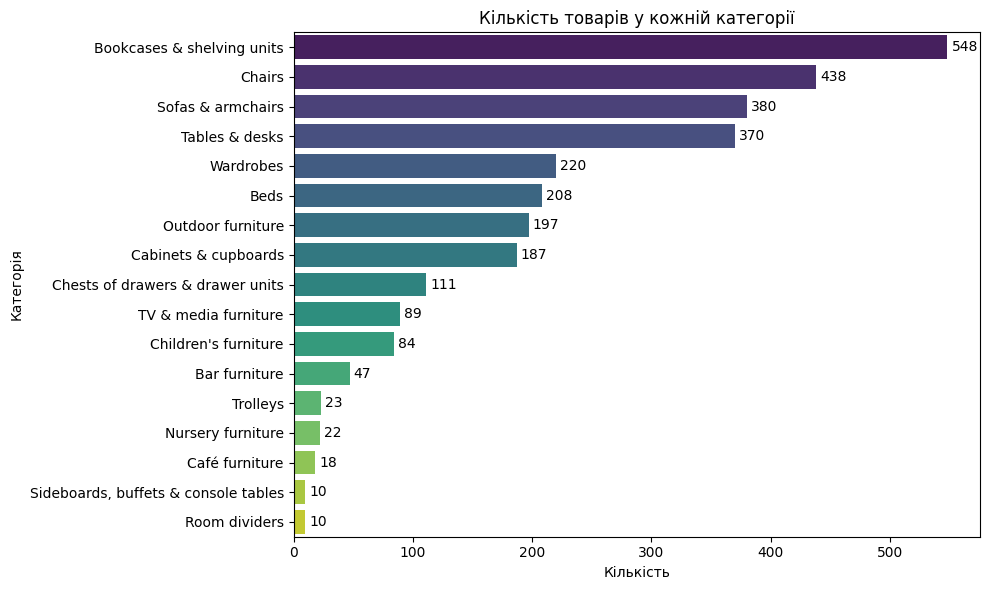

In [80]:
plt.figure(figsize=(10, 6))
order = df_base['category'].value_counts().index
ax = sns.countplot(data=df_base, y='category', order=order, palette='viridis')  

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Кількість товарів у кожній категорії')
plt.xlabel('Кількість')
plt.ylabel('Категорія')
plt.tight_layout() 
plt.show()


In [81]:
print((df_base.groupby('category')['price'].median().sort_values(ascending=False)).to_markdown())

| category                             |   price |
|:-------------------------------------|--------:|
| Wardrobes                            |  1950   |
| Sofas & armchairs                    |  1157   |
| Beds                                 |  1093.5 |
| Sideboards, buffets & console tables |   927.5 |
| TV & media furniture                 |   860   |
| Cabinets & cupboards                 |   845   |
| Room dividers                        |   595   |
| Trolleys                             |   537   |
| Chests of drawers & drawer units     |   499   |
| Chairs                               |   497   |
| Tables & desks                       |   475   |
| Bar furniture                        |   445   |
| Café furniture                       |   370   |
| Outdoor furniture                    |   345   |
| Nursery furniture                    |   322.5 |
| Bookcases & shelving units           |   310   |
| Children's furniture                 |   202.5 |


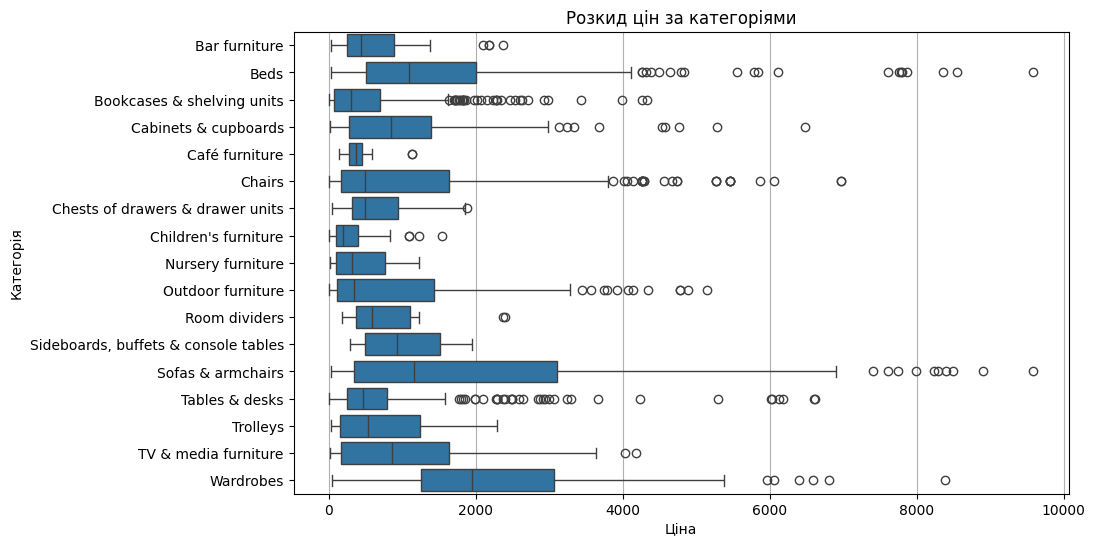

In [82]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_base, x='price', y='category')
plt.title('Розкид цін за категоріями')
plt.xlabel('Ціна')
plt.ylabel('Категорія')
plt.grid(axis='x') 
plt.show()

Провівши кількісний та ціновий аналіз товарів за категорією бачимо, що кількісно переважають категорії Bookcases & Shelving units,
Chairs, Sofas & Armchairs та Table & Desks найдорожчою категорією є 'Wardrobes', 'Sofas & armchairs' та 'Beds'. 

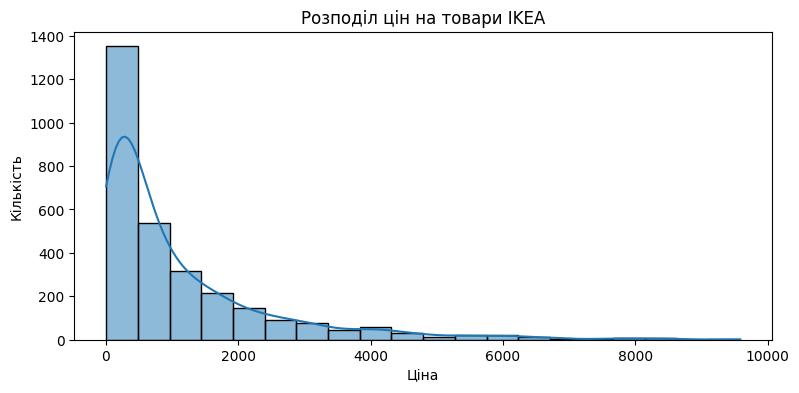

In [83]:
plt.figure(figsize=(9,4))
sns.histplot(df_base['price'], kde=True, bins=20)
plt.title('Розподіл цін на товари IKEA')
plt.xlabel('Ціна')
plt.ylabel('Кількість')
plt.show()

Ми бачимо, що розподіл ціни сильно зміщений вправо (positive skew). Більшість меблів IKEA коштують до 2000 одиниць, але є поодинокі екземпляри дорожче 8000. Це означає, що середня ціна буде вищою за медіану.
Оскільки високі ціни є реальними ринковими даними для певних категорій (наприклад, гардеробів), я вирішила не видаляти їх, щоб модель могла розпізнавати дорогі сегменти. 

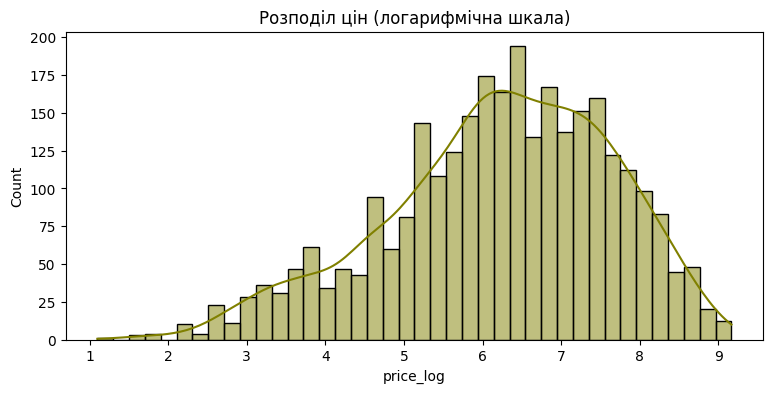

In [84]:
plt.figure(figsize=(9, 4))
df_base['price_log'] = np.log(df_base['price']) 
sns.histplot(df_base['price_log'], kde=True, binwidth=0.2, color='olive')
plt.title('Розподіл цін (логарифмічна шкала)')
plt.show()

Для стабілізації дисперсії та приведення розподілу цільової змінної до нормального вигляду було застосовано логарифмічне перетворення (log-transformation).
Це дозволяє зменшити вплив цінових викидів та покращити якість майбутньої прогнозної моделі.

In [85]:
df_base['sellable_online'].value_counts(normalize=True)                                         

sellable_online
True     0.993585
False    0.006415
Name: proportion, dtype: float64

C:\Users\Anna\AppData\Local\Temp\ipykernel_14524\1036427866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_base, x='sellable_online', palette='viridis')


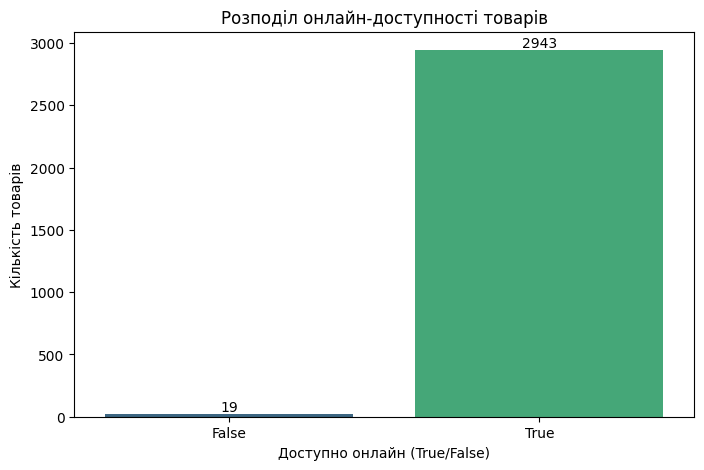

In [86]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_base, x='sellable_online', palette='viridis')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Розподіл онлайн-доступності товарів')
plt.xlabel('Доступно онлайн (True/False)')
plt.ylabel('Кількість товарів')
plt.show()

Аналіз стовпця sellable_online показав, що понад 99% товарів доступні для онлайн-замовлення. Через відсутність варіативності, ця ознака не несе інформативного навантаження для побудови прогнозних моделей і може бути вилучена з подальшого розгляду.

In [87]:
df_base.drop(columns=['sellable_online'], inplace=True)

In [88]:
df_base['other_colors'].value_counts(normalize=True) 

other_colors
No     0.552667
Yes    0.447333
Name: proportion, dtype: float64

C:\Users\Anna\AppData\Local\Temp\ipykernel_14524\649557332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_base, x='other_colors', palette='Blues', edgecolor='black')


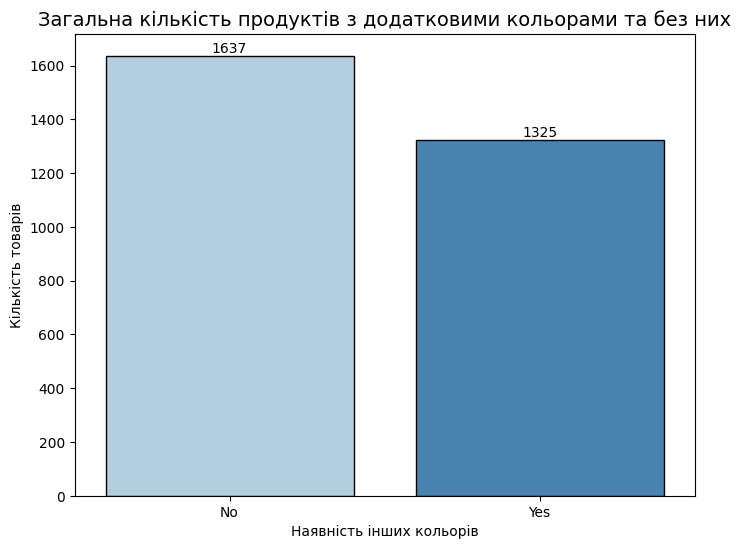

In [89]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_base, x='other_colors', palette='Blues', edgecolor='black')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Загальна кількість продуктів з додатковими кольорами та без них', fontsize=14)
plt.xlabel('Наявність інших кольорів')
plt.ylabel('Кількість товарів')
plt.show()

C:\Users\Anna\AppData\Local\Temp\ipykernel_14524\2634378903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_price = sns.barplot(data=price_median, x='other_colors', y='price', palette='magma', edgecolor='black')


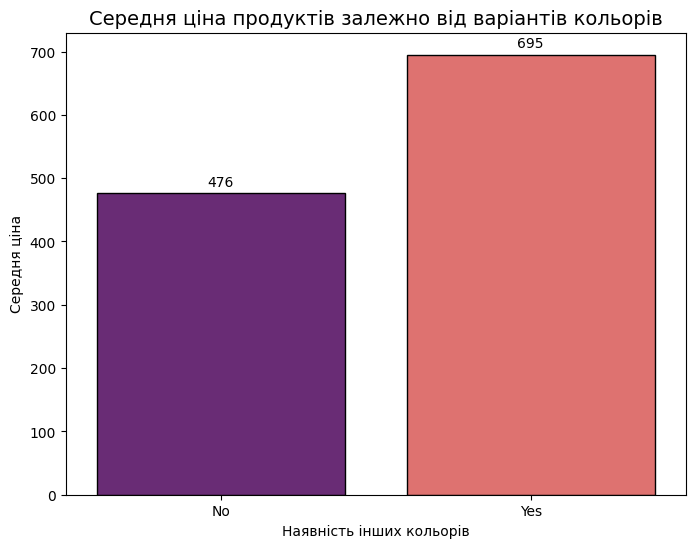

In [90]:
plt.figure(figsize=(8, 6))
price_median = df_base.groupby('other_colors')['price'].median().reset_index()
ax_price = sns.barplot(data=price_median, x='other_colors', y='price', palette='magma', edgecolor='black')
for i in ax_price.containers:
    ax_price.bar_label(i, fmt='%.0f', padding=3)
plt.title('Середня ціна продуктів залежно від варіантів кольорів', fontsize=14)
plt.xlabel('Наявність інших кольорів')
plt.ylabel('Середня ціна')
plt.show()

Ціновий розрив: Середня ціна товарів з додатковими кольорами (745) на 50% вища, ніж у товарів без них (495). Це статистичний факт у межах цього датасету.
Розподіл у каталозі: Товари без додаткових кольорів складають більшість асортименту (55%), але група з кольорами також є значною (45%).

In [91]:
df_base['designer'].unique()

array(['Nicholai Wiig Hansen', 'Francis Cayouette', 'Henrik Preutz',
       'Marcus Arvonen', 'Carina Bengs', 'K Hagberg/M Hagberg',
       'Sarah Fager', 'Ehlén Johansson', 'Nike Karlsson',
       'Maja Ganszyniec', 'Karl Malmvall',
       'John/Jonas/Petrus/Paul/Caroline', 'Nike Karlsson/Maja Ganszyniec',
       'J Karlsson/N Karlsson', 'IKEA of Sweden/Karl Malmvall',
       'IKEA of Sweden', 'Nike Karlsson/J Karlsson/N Karlsson',
       'Ola Wihlborg', 'IKEA of Sweden/Tina Christensen',
       'IKEA of Sweden/K Hagberg/M Hagberg',
       'Ola Wihlborg/IKEA of Sweden',
       '504.689.53 Small and easy-to-place chair-bed which can easily be converted into a single bed.The storage space under the seat has room for bedlinen or other things.Just as nice to look at from all sides – perfect to place in the middle of the room or use as a room divider.The cushion cover is easy to keep clean and fresh, as you can take it off and machine-wash it.Easy to assemble.1 cushion included.',
       '

In [92]:
mask = ~df_base["designer"].str.contains(r'\d', na=False)
df_base = df_base.loc[mask].copy()

In [93]:
df_base.loc[:, 'designer'] = df_base['designer'].str.replace(r'K Hagberg\s*/\s*M Hagberg', 'Hagberg family',regex=True)

In [94]:
df_base['designer'].unique()

array(['Nicholai Wiig Hansen', 'Francis Cayouette', 'Henrik Preutz',
       'Marcus Arvonen', 'Carina Bengs', 'Hagberg family', 'Sarah Fager',
       'Ehlén Johansson', 'Nike Karlsson', 'Maja Ganszyniec',
       'Karl Malmvall', 'John/Jonas/Petrus/Paul/Caroline',
       'Nike Karlsson/Maja Ganszyniec', 'J Karlsson/N Karlsson',
       'IKEA of Sweden/Karl Malmvall', 'IKEA of Sweden',
       'Nike Karlsson/J Karlsson/N Karlsson', 'Ola Wihlborg',
       'IKEA of Sweden/Tina Christensen', 'IKEA of Sweden/Hagberg family',
       'Ola Wihlborg/IKEA of Sweden', 'IKEA of Sweden/Ebba Strandmark',
       'Hagberg family/IKEA of Sweden', 'Jon Karlsson',
       'IKEA of Sweden/Carina Bengs', 'David Wahl',
       'Jon Karlsson/IKEA of Sweden', 'IKEA of Sweden/Paulin Machado',
       'IKEA of Sweden/Eva Lilja Löwenhielm',
       'IKEA of Sweden/Synnöve Mork/Ola Wihlborg',
       'IKEA of Sweden/David Wahl', 'Ebba Strandmark/IKEA of Sweden',
       'Eva Lilja Löwenhielm', 'IKEA of Sweden/Anna Efverlu

In [95]:
def clean_designer_final(text):
    if pd.isna(text):
        return "Unknown"
    parts = re.split(r'[/,]| \band\b ', text)
    
    parts = [p.strip() for p in parts if p.strip()]
    
    if len(parts) > 1 and "IKEA of Sweden" in parts:
        parts.remove("IKEA of Sweden")

    if not parts:
        return "IKEA of Sweden"
    
    if parts[0] == "John":
        return "IKEA Team"
        
    return parts[0]

df_base['designer_cleaned'] = df_base['designer'].apply(clean_designer_final)


In [96]:
print(df_base['designer_cleaned'].value_counts().head(15).to_markdown())  

| designer_cleaned     |   count |
|:---------------------|--------:|
| IKEA of Sweden       |     683 |
| Ehlén Johansson      |     310 |
| Ola Wihlborg         |     174 |
| Francis Cayouette    |     168 |
| Jon Karlsson         |     155 |
| Hagberg family       |     134 |
| Ebba Strandmark      |      83 |
| Henrik Preutz        |      78 |
| Eva Lilja Löwenhielm |      75 |
| Carina Bengs         |      71 |
| K Malmvall           |      55 |
| Nike Karlsson        |      55 |
| Marcus Arvonen       |      52 |
| Tord Björklund       |      46 |
| David Wahl           |      46 |


In [97]:
sorted_designers= sorted(df_base['designer_cleaned'].unique().astype(str))
for name in sorted_designers:
    print(name)  

A Fredriksson
A Huldén
Andreas Fredriksson
Anna Efverlund
Anna Palleschitz
Annie Huldén
C Halskov
C Styrbjörn
Carina Bengs
Carl Öjerstam
Charlie Styrbjörn
Chenyi Ke
Chris Martin
David Wahl
E Strandmark
E Thomasson
Ebba Strandmark
Ehlén Johansson
Elizabet Gutierrez
Eva Lilja Löwenhielm
Eva Schildt
Francis Cayouette
Fredriksson
Gillis Lundgren
Gustav Carlberg
H Preutz
HAY
Hagberg family
Henrik Preutz
IKEA Team
IKEA of Sweden
J Asshoff
J Fritzdorf
J Karlsson
J Löfgren
Johan Kroon
Johanna Asshoff
Johanna Jelinek
Jomi Evers
Jon Karlsson
Jonas Hultqvist
Jooyeon Lee
K Malmvall
Karl Malmvall
L Hilland
Lars Norinder
Lisa Hilland
Lisa Norinder
Lisel Garsveden
Lycke von Schantz
M Kjelstrup
Magnus Elebäck
Maja Ganszyniec
Malin Unnborn
Marcus Arvonen
Maria Vinka
Mia Lagerman
Mikael Axelsson
Mikael Warnhammar
Monika Mulder
Nada Debs
Nicholai Wiig Hansen
Niels Gammelgaard
Nike Karlsson
Noboru Nakamura
Ola Wihlborg
Olle Lundberg
P Süssmann
Paulin Machado
S Edholm
S Fager
S Holmbäck
S Lanneskog
Sarah F

In [98]:
final_name_fixer = {
    'A Fredriksson': 'Andreas Fredriksson',
    'A Huldén': 'Annie Huldén',
    'C Styrbjörn': 'Charlie Styrbjörn',
    'E Strandmark': 'Ebba Strandmark',
    'E Lilja Löwenhielm': 'Eva Lilja Löwenhielm',                                                   
    'Fredriksson': 'Andreas Fredriksson',
    'Hilland': 'Lisa Hilland',
    'H Preutz': 'Henrik Preutz',
    'J Asshoff': 'Johanna Asshoff',
    'J Hultqvist': 'Jonas Hultqvist',
    'J Jelinek': 'Johanna Jelinek',
    'J Karlsson': 'Jon Karlsson',
    'K Malmvall': 'Karl Malmvall',
    'L Löwenhielm': 'Eva Lilja Löwenhielm',
    'L Hilland': 'Lisa Hilland',
    'M Axelsson': 'Mikael Axelsson',
    'S Fager': 'Sarah Fager',
    'T Christensen': 'Tina Christensen',
    'N Karlsson': 'Nike Karlsson'
}


df_base['designer_final'] = df_base['designer_cleaned'].map(lambda x: final_name_fixer.get(x, x))


In [99]:
sort_des_rep = sorted(df_base['designer_final'].unique().astype(str))
for name in sort_des_rep:
    print(name)

Andreas Fredriksson
Anna Efverlund
Anna Palleschitz
Annie Huldén
C Halskov
Carina Bengs
Carl Öjerstam
Charlie Styrbjörn
Chenyi Ke
Chris Martin
David Wahl
E Thomasson
Ebba Strandmark
Ehlén Johansson
Elizabet Gutierrez
Eva Lilja Löwenhielm
Eva Schildt
Francis Cayouette
Gillis Lundgren
Gustav Carlberg
HAY
Hagberg family
Henrik Preutz
IKEA Team
IKEA of Sweden
J Fritzdorf
J Löfgren
Johan Kroon
Johanna Asshoff
Johanna Jelinek
Jomi Evers
Jon Karlsson
Jonas Hultqvist
Jooyeon Lee
Karl Malmvall
Lars Norinder
Lisa Hilland
Lisa Norinder
Lisel Garsveden
Lycke von Schantz
M Kjelstrup
Magnus Elebäck
Maja Ganszyniec
Malin Unnborn
Marcus Arvonen
Maria Vinka
Mia Lagerman
Mikael Axelsson
Mikael Warnhammar
Monika Mulder
Nada Debs
Nicholai Wiig Hansen
Niels Gammelgaard
Nike Karlsson
Noboru Nakamura
Ola Wihlborg
Olle Lundberg
P Süssmann
Paulin Machado
S Edholm
S Holmbäck
S Lanneskog
Sarah Fager
Studio Copenhagen
Synnöve Mork
T Winkel
Thomas Sandell
Tina Christensen
Tom Dixon
Tord Björklund
Virgil Abloh
Wieb

In [100]:
print(df_base['designer_final'].value_counts().head(15).to_markdown())

| designer_final       |   count |
|:---------------------|--------:|
| IKEA of Sweden       |     683 |
| Ehlén Johansson      |     310 |
| Ola Wihlborg         |     174 |
| Jon Karlsson         |     169 |
| Francis Cayouette    |     168 |
| Hagberg family       |     134 |
| Henrik Preutz        |     110 |
| Ebba Strandmark      |      87 |
| Eva Lilja Löwenhielm |      75 |
| Carina Bengs         |      71 |
| Karl Malmvall        |      60 |
| Nike Karlsson        |      55 |
| Marcus Arvonen       |      52 |
| Andreas Fredriksson  |      51 |
| Tord Björklund       |      46 |


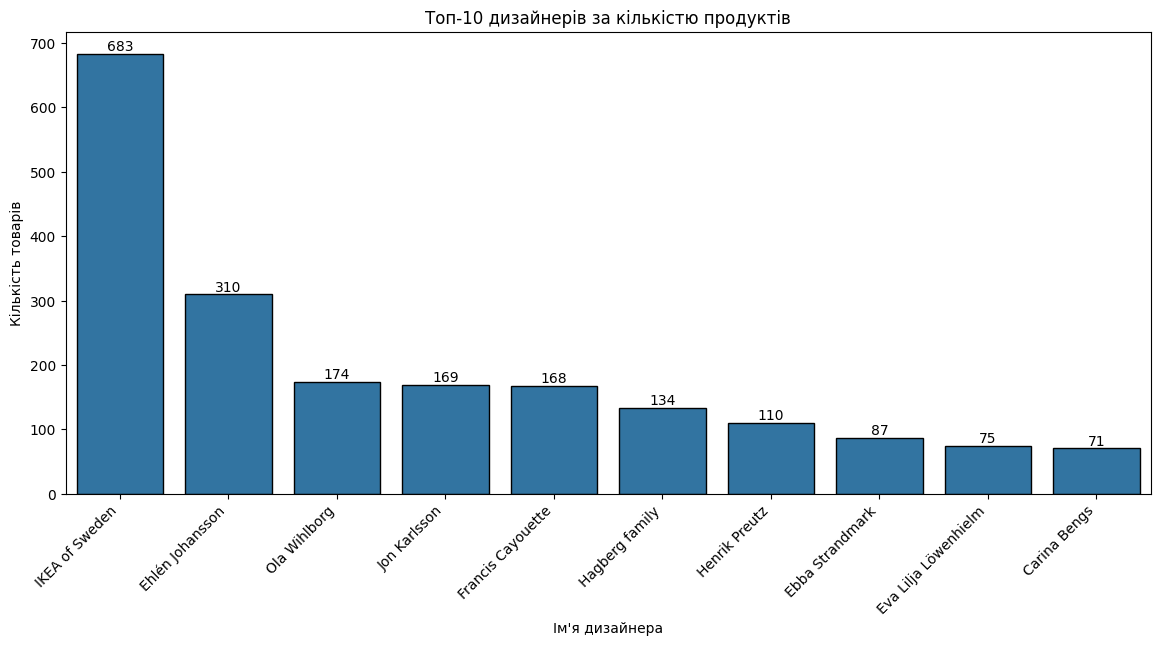

In [101]:
plt.figure(figsize=(14, 6))
top_designer = df_base['designer_final'].value_counts().nlargest(10).reset_index()
top_designer.columns = ['designer_final', 'product_count']
barplot = sns.barplot(data=top_designer, x='designer_final', y='product_count', edgecolor='black')
for i in barplot.containers:
    barplot.bar_label(i)
plt.xticks(rotation=45, ha='right')
plt.title("Топ-10 дизайнерів за кількістю продуктів")
plt.xlabel("Ім'я дизайнера")
plt.ylabel("Кількість товарів")
plt.show()

Найбільший внесок в асортимент робить команда IKEA of Sweden (683 унікальні позиції). Серед індивідуальних авторів найпродуктивнішими є Ehlén Johansson та Ola Wihlborg.

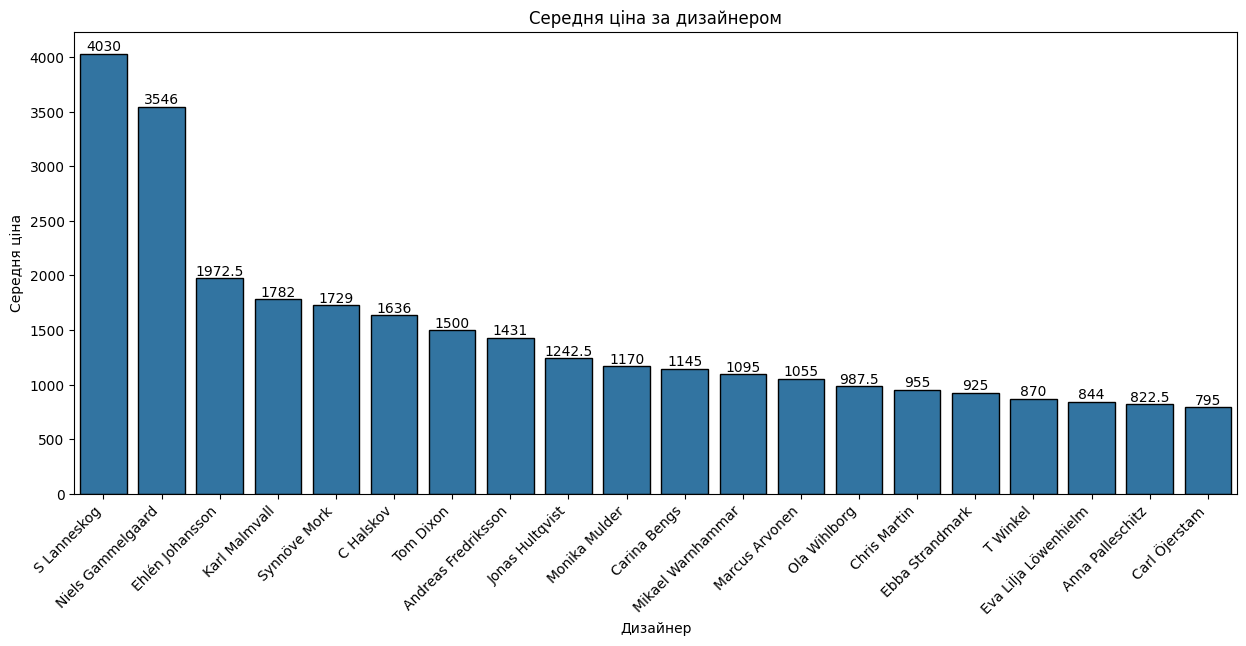

In [102]:
plt.figure(figsize=(15, 6))
designer_price = df_base.groupby('designer_final')['price'].median().nlargest(20).reset_index()
designer_price_plot = sns.barplot(data=designer_price, x='designer_final', y='price', edgecolor='black')
for i in designer_price_plot.containers:
    designer_price_plot.bar_label(i)
plt.title('Середня ціна за дизайнером')
plt.xlabel('Дизайнер')
plt.ylabel('Середня ціна')
plt.xticks(rotation=45, ha='right')
plt.show()

Візуалізація підтвердила значну варіативність цін залежно від авторства. Виявлено "преміальний" сегмент дизайнерів (наприклад, S Lanneskog із середньою ціною > 4000 та Niels Gammelgaard > 3000), що робить колонку дизайнера критично важливою для прогнозування вартості.

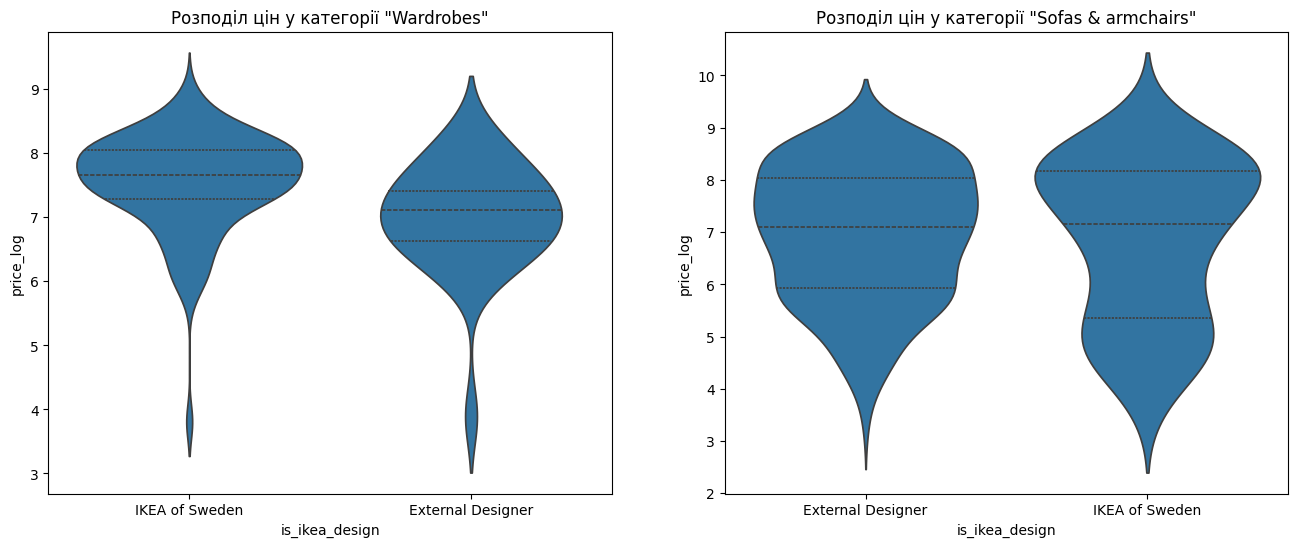

In [103]:
df_base['is_ikea_design'] = df_base['designer'].apply(
    lambda x: 'IKEA of Sweden' if 'IKEA of Sweden' in str(x) else 'External Designer'
)
plt.figure(figsize=(16, 6)) 

plt.subplot(1, 2, 1) 
top_category_1 = 'Wardrobes'
category_df_1 = df_base[df_base['category'] == top_category_1]
sns.violinplot(x='is_ikea_design', y='price_log', data=category_df_1, inner="quart")
plt.title(f'Розподіл цін у категорії "{top_category_1}"')


plt.subplot(1, 2, 2) 
top_category_2 = 'Sofas & armchairs'
category_df_2 = df_base[df_base['category'] == top_category_2]
sns.violinplot(x='is_ikea_design', y='price_log', data=category_df_2, inner="quart")
plt.title(f'Розподіл цін у категорії "{top_category_2}"')

plt.show() 

In [104]:
print(df_base[['width', 'height', 'depth']].isnull().sum().to_markdown())   

|        |    0 |
|:-------|-----:|
| width  |  414 |
| height |  695 |
| depth  | 1062 |


In [105]:
for col in ['depth', 'height', 'width']:
    df_base[col] = df_base[col].fillna(df_base.groupby('category')[col].transform('median'))

In [106]:
print(df_base[['width', 'height', 'depth']].isnull().sum().to_markdown()) 

|        |   0 |
|:-------|----:|
| width  |   0 |
| height |   0 |
| depth  |   0 |


In [107]:
df_base['volume'] = df_base['width'] * df_base['height'] * df_base['depth']

Text(0.5, 1.0, 'Кореляція Спірмена: ціна та розмір')

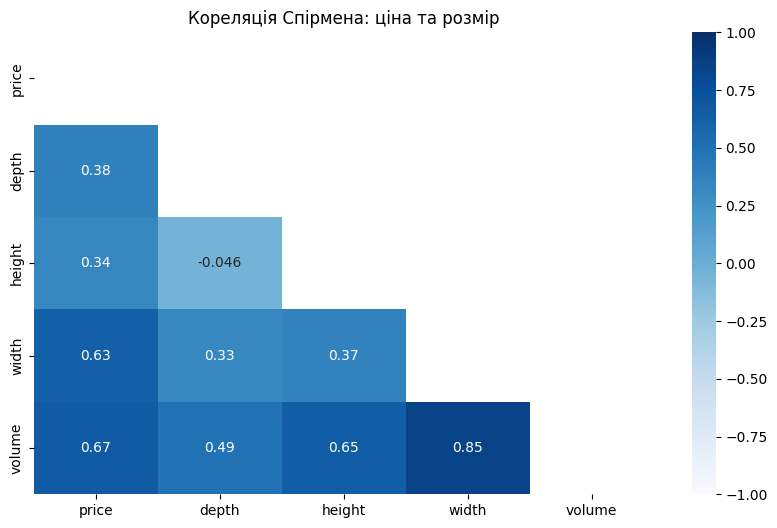

In [108]:
plt.figure(figsize=(10, 6))
correlation_spearman = df_base[['price', 'depth', 'height', 'width', 'volume']].corr(method='spearman')
mask = np.triu(np.ones_like(correlation_spearman, dtype=bool))
sns.heatmap(correlation_spearman, annot=True, mask=mask, cmap='Blues', vmin=-1, vmax=1)
plt.title('Кореляція Спірмена: ціна та розмір')

Кореляційний аналіз підтвердив, що габарити виробу є значущими предикторами ціни. Найвищий рівень кореляції спостерігається між шириною та вартістю 
(r = 0.63). Низька взаємозалежність між самими габаритами (від -0.046 до 0.37) 
свідчить про відсутність мультиколінеарності, що дозволяє використовувати всі три виміри як незалежні ознаки в моделі машинного навчання.

Гіпотеза №1: Вплив дизайнера на ціну
Формулювання: Дизайнер суттєво впливає на ціноутворення продукту.
Нульова гіпотеза: Медіанні ціни на товари різних дизайнерів однакові (дизайнер не впливає на ціну).
Альтернативна гіпотеза: Існує статистично значуща різниця в цінах між різними дизайнерами.

Гіпотеза №2: Зв'язок ширини та ціни
Формулювання: Ціна продукту прямо залежить від його загального об'єму (V = W * H * D).
Нульова гіпотеза: Між об'ємом товару та його ціною немає статистично значущого зв'язку (кореляція дорівнює 0).
Альтернативна гіпотеза: Існує сильна позитивна кореляція між об'ємом та ціною.

Перед перевіркою гіпотез перевіряємо розподіл даних в дата сеті.

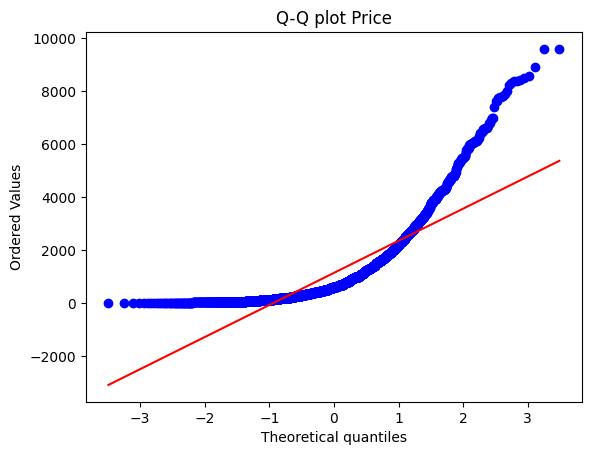

In [109]:
stats.probplot(df_base['price'], dist="norm", plot=plt)
plt.title("Q-Q plot Price")
plt.show()

In [110]:
stat, p = stats.shapiro(df_base['price'])

print(f'Статистика тесту: {stat:.4f}')
print(f'p-value: {p:.4e}')

alpha = 0.05
if p > alpha:
    print("Дані розподілені нормально.")
else:
    print("Дані НЕ розподілені нормально (це очікувано для цін).")

Статистика тесту: 0.7385
p-value: 2.8120e-55
Дані НЕ розподілені нормально (це очікувано для цін).


Я провела тест Шапіро-Вілка та подивилася на QQ-plot, щоб перевірити ціни на нормальність. Отримала p < 0.05, отже, дані розподілені ненормально. Оскільки припущення про нормальність порушено, я не можу використовувати звичайний ANOVA. 

In [111]:
designer_counts = df_base['designer_final'].value_counts()
cumulative_share = designer_counts.cumsum() / designer_counts.sum()
top_designers = cumulative_share[cumulative_share <= 0.50].index

df_base['designer_hypothesis'] = df_base['designer_final'].apply(   
    lambda x: x if x in top_designers else 'Other'                                                                 ########"Поверни x (саме ім'я), ЯКЩО цей x є у списку топів, ІНАКШЕ поверни слово 'Other'
)

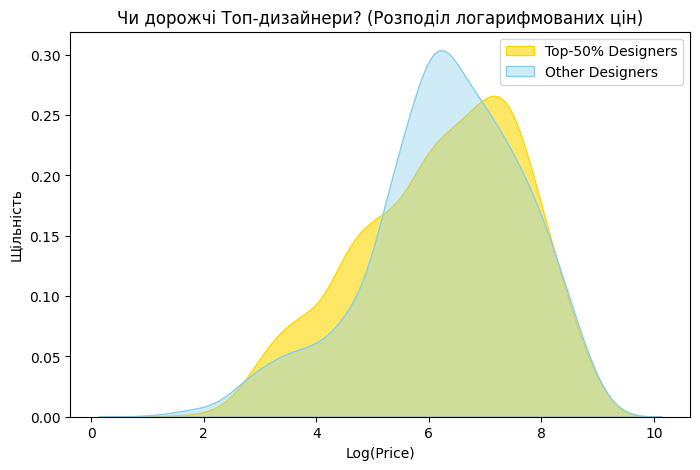

In [112]:
plt.figure(figsize=(8, 5))

sns.kdeplot(data=df_base[df_base['designer_hypothesis'] != 'Other'], x='price_log', 
            fill=True, label='Top-50% Designers', color='gold', alpha=0.6)
sns.kdeplot(data=df_base[df_base['designer_hypothesis'] == 'Other'], x='price_log', 
            fill=True, label='Other Designers', color='skyblue', alpha=0.4)

plt.title('Чи дорожчі Топ-дизайнери? (Розподіл логарифмованих цін)')
plt.xlabel('Log(Price)')
plt.ylabel('Щільність')
plt.legend()
plt.show()

Візуальний аналіз щільності розподілу (KDE) підтверджує, що цінові стратегії топ-дизайнерів та інших авторів відрізняються. Перевіромо це ще раз за допомогою тесту Мана -Вітні.

In [113]:
top_group_prices = df_base[df_base['designer_hypothesis'] != 'Other']['price']
other_group_prices = df_base[df_base['designer_hypothesis'] == 'Other']['price']

stat, p_val = stats.mannwhitneyu(top_group_prices, other_group_prices)

print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Висновок: Різниця значуща. Топ-дизайнери мають іншу цінову політику.")
else:
    print("Висновок: Різниця випадкова. Ім'я дизайнера не впливає на ціну так сильно.")

P-value: 3.6446e-01
Висновок: Різниця випадкова. Ім'я дизайнера не впливає на ціну так сильно.


Статистичний тест (Mann-Whitney U) показав p-value = 0.364, що значно > за поріг 0.05. Це означає, що ми не можемо відкинути нульову гіпотезу. Статистично значущої різниці між цінами "Топ-дизайнерів" та іншими авторами не виявлено. Оскільки імена дизайнерів не мають прямого впливу на ціноутворення, цей фактор не буде пріоритетним для нашої моделі ML. Переходимо до перевірки Гіпотези №2.

In [114]:
corr_spearman, p_val_spearman = stats.spearmanr(df_base['volume'], df_base['price'])
print(f"Correlation coefficient: {corr_spearman:.4f}")
print(f"P-value: {p_val_spearman:.4e}")
if p_val_spearman < 0.05:
   
    strength = "strong" if corr_spearman > 0.5 else "moderate"
    print(f"Conclusion: Relationship confirmed. A coefficient of {corr_spearman:.2f} indicates a {strength} positive correlation.")
else:
    print("Conclusion: No significant relationship between volume and price was found.")

Correlation coefficient: 0.6669
P-value: 0.0000e+00
Conclusion: Relationship confirmed. A coefficient of 0.67 indicates a strong positive correlation.


Коефіцієнт кореляції Спірмена 0.67 та p-value < 0.05 підтверджують наявність сильного позитивного зв'язку між об'ємом товару та його ціною.

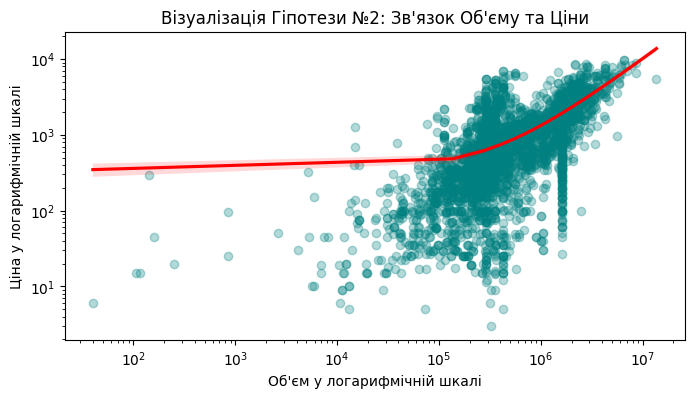

In [115]:
plt.figure(figsize=(8, 4))

sns.regplot(data=df_base, x='volume', y='price', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.xscale('log')
plt.yscale('log')

plt.title('Візуалізація Гіпотези №2: Зв\'язок Об\'єму та Ціни')
plt.xlabel('Об\'єм у логарифмічній шкалі')
plt.ylabel('Ціна у логарифмічній шкалі')

plt.show()

Візуалізація (Scatter Plot) продемонструвала чітку тенденцію: зі збільшенням фізичних габаритів товару його вартість зростає. Хоча існують винятки (дороговартісні малогабаритні товари), загальний об'єм є ключовим ціноутворюючим фактором для асортименту IKEA.

# Data Preparation

In [116]:
ml_data = df_base.copy()

In [117]:
ml_data.columns

Index(['name', 'category', 'price', 'old_price', 'other_colors',
       'short_description', 'designer', 'depth', 'height', 'width',
       'price_log', 'designer_cleaned', 'designer_final', 'is_ikea_design',
       'volume', 'designer_hypothesis'],
      dtype='object')

In [118]:
ml_data.drop(columns=['name','old_price', 'short_description', 'price_log', 'designer', 'designer_cleaned', 
                      'designer_final', 'designer_hypothesis'], inplace=True)

In [119]:
ml_data.columns

Index(['category', 'price', 'other_colors', 'depth', 'height', 'width',
       'is_ikea_design', 'volume'],
      dtype='object')

In [120]:
features = ['category', 'depth', 'height', 'width', 'volume', 'other_colors']
X = ml_data[features]
y = ml_data['price']

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Тренувальні дані: {X_train.shape}")
print(f"Тестові дані: {X_test.shape}")

Тренувальні дані: (2288, 6)
Тестові дані: (572, 6)


In [122]:
numeric_features = ['width', 'height', 'depth', 'volume']
categorical_features = ['category', 'other_colors']

## Створюємо "рецепт" обробки для чисел
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), ## Якщо в даних пропуски програма автоматично підставить туди медіану по цьому стовпцю.
    ('scaler', StandardScaler())       ##  Це масштабування. Моделі важко працювати, коли одне число — 5000 (ціна), а інше — 0.5 (глибина). Скалер приводить їх до одного масштабу (зазвичай від -3 до 3), щоб великі числа не "тиснули" на модель сильніше за малі.
          
])

 ## Pipeline для категорій: заповнюємо пропуски модою + TargetEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), ## Пропуски в категоріях (наприклад, не вказано колір) заповнюються модою (найбільш популярним значенням).
    ('encoder', TargetEncoder(target_type='continuous')) ## Замість того, щоб просто присвоїти категорії числа (1, 2, 3), цей енкодер замінює назву категорії на середнє значення ціни для цієї категорії. Наприклад, якщо категорія "Дивани" зазвичай дорога, вона отримає високе числове значення. Це допомагає моделі краще зрозуміти зв'язок між категорією та ціною.
])


col_prepr = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

col_prepr

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [123]:
def getBestRegressor(X_train, X_test, Y_train, Y_test, col_prepr):
   
    models = [
        LinearRegression(),
        LassoCV(),
        RidgeCV(),
        SVR(kernel="linear"), 
        KNeighborsRegressor(n_neighbors=16),
        DecisionTreeRegressor(max_depth=10, random_state=42),
        RandomForestRegressor(random_state=42),
        GradientBoostingRegressor(),
        BaggingRegressor(random_state=42),
        HistGradientBoostingRegressor(),
        XGBRegressor(objective="reg:squarederror", random_state=42)
    ]

    results_list = [] 

    for model in models:
        
        model_pipeline = Pipeline(steps=[
            ('col_prepr', col_prepr),
            ('to_dense', FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x)),
            ('model', model)
        ])

        model_pipeline.fit(X_train, Y_train)
        
        # Прогноз
        y_pred = model_pipeline.predict(X_test)


        results_list.append({
            "Model": model.__class__.__name__,
            "R^2": r2_score(Y_test, y_pred),
            "MAE": mean_absolute_error(Y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(Y_test, y_pred))
        })

    test_models_df = pd.DataFrame(results_list)
    test_models_df = test_models_df.sort_values(by="R^2", ascending=False).set_index("Model")

    return {
        "report": test_models_df,
        "X_train": X_train,
        "Y_train": Y_train,
        "X_test": X_test,
        "Y_test": Y_test
    }

results = getBestRegressor(X_train, X_test, y_train, y_test, col_prepr)
print(results["report"])


                                    R^2         MAE         RMSE
Model                                                           
RandomForestRegressor          0.806838  392.096054   651.857382
BaggingRegressor               0.777761  417.152342   699.200020
XGBRegressor                   0.776577  409.903250   701.060352
HistGradientBoostingRegressor  0.769745  416.807411   711.698065
DecisionTreeRegressor          0.752835  446.893690   737.369377
GradientBoostingRegressor      0.717932  465.973450   787.713113
LinearRegression               0.473544  652.433052  1076.148959
RidgeCV                        0.472790  651.725965  1076.919185
SVR                            0.383593  656.168469  1164.461267
KNeighborsRegressor            0.372517  703.154261  1174.876284
LassoCV                        0.366801  747.077203  1180.215757


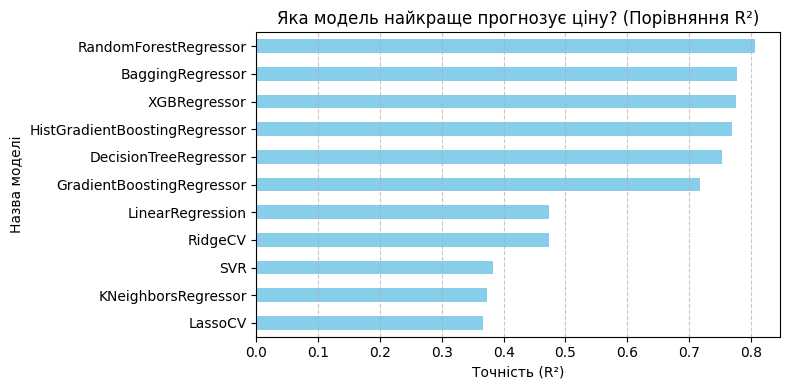

In [124]:
df_report = results['report']

plt.figure(figsize=(8, 4))

df_report['R^2'].sort_values().plot(kind='barh', color='skyblue')

plt.title('Яка модель найкраще прогнозує ціну? (Порівняння R²)')
plt.xlabel('Точність (R²)')
plt.ylabel('Назва моделі')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [132]:
final_pipe = Pipeline(steps=[
    ('col_prepr', col_prepr),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 300],                                               # Кількість дерев
    'model__max_depth': [10, 20, None],                                              # Обмежуємо глибину (як просив ментор)
    'model__min_samples_leaf': [1, 2, 4],                                            # Мінімальна кількість об'єктів у листку
    'model__max_features': ['sqrt', 'log2']                                          # Використовуємо всі ознаки або корінь з них
}

grid_search = GridSearchCV(final_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкращий R^2 після тюнінгу: {grid_search.best_score_:.4f}")

best_model_upg = grid_search.best_estimator_

Найкращі параметри: {'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Найкращий R^2 після тюнінгу: 0.7650


In [133]:
final_scores = cross_val_score(best_model_upg, X_train, y_train, cv=5, scoring='r2')
print(f"Результати крос-валідації: {final_scores}")
print(f"Середній R^2: {final_scores.mean():.4f}")
print(f"Відхилення (стабільність): {final_scores.std():.4f}")

Результати крос-валідації: [0.80591355 0.75580125 0.7573356  0.76851815 0.74493334]
Середній R^2: 0.7665
Відхилення (стабільність): 0.0211


In [134]:
best_model = Pipeline(steps=[
    ('col_prepr', col_prepr),
    ('model', RandomForestRegressor(random_state=42))
])

final_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')

print(f"Результати крос-валідації (дефолт): {final_scores}")
print(f"Середній R^2: {final_scores.mean():.4f}")
print(f"Відхилення (стабільність): {final_scores.std():.4f}")

Результати крос-валідації (дефолт): [0.76344284 0.74255524 0.73425423 0.75464821 0.75849056]
Середній R^2: 0.7507
Відхилення (стабільність): 0.0107


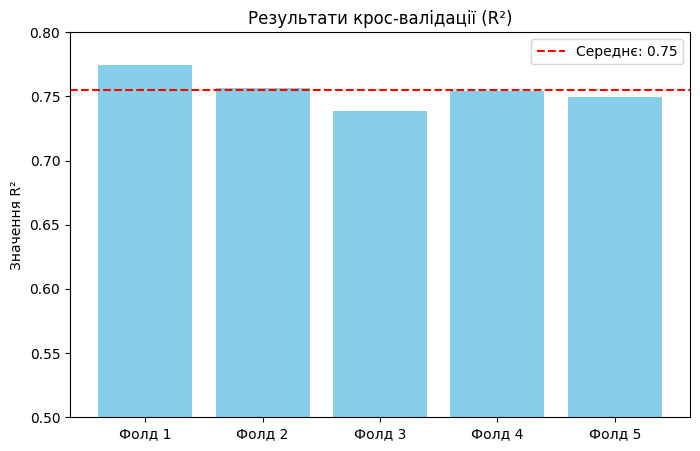

In [128]:
plt.figure(figsize=(8, 5))
bars = plt.bar(['Фолд 1', 'Фолд 2', 'Фолд 3', 'Фолд 4', 'Фолд 5'], final_scores, color='skyblue')
plt.ylim(0.5, 0.8) 
plt.axhline(y=final_scores.mean(), color='red', linestyle='--', label=f'Середнє: {final_scores.mean():.2f}')
plt.title('Результати крос-валідації (R²)')
plt.ylabel('Значення R²')
plt.legend()

plt.show()

# Machine Learning

In [136]:
final_model = best_model_upg
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 

print("=== ФІНАЛЬНИЙ ЗВІТ МОДЕЛІ ===")
print(f"R^2 (Точність):        {r2:.4f}")
print(f"MAE (Сер. помилка):     {mae:.2f} грн")
print(f"MSE (Квадр. помилка):   {mse:.2f}")
print(f"RMSE (Корінь з MSE):    {rmse:.2f} грн")

=== ФІНАЛЬНИЙ ЗВІТ МОДЕЛІ ===
R^2 (Точність):        0.7957
MAE (Сер. помилка):     385.83 грн
MSE (Квадр. помилка):   449457.90
RMSE (Корінь з MSE):    670.42 грн


In [6]:

importances = best_model.named_steps['model'].feature_importances_

)
feature_names = numeric_features + categorical_features


importance_df = pd.DataFrame({'Фактор': feature_names, 'Важливість': importances})

final_report = importance_df.groupby('Фактор').sum().sort_values(by='Важливість', ascending=False)
final_report['Вплив (%)'] = final_report['Важливість'] * 100

print(final_report[['Вплив (%)']])

SyntaxError: unmatched ')' (3458678841.py, line 3)

In [ ]:
plt.figure(figsize=(8, 4))
final_report['Вплив (%)'].plot(kind='bar', color='skyblue')
plt.title('Що найбільше впливає на ціну?')
plt.ylabel('Відсотки (%)')
plt.xticks(rotation=45)
plt.show()

Для прогнозування цін IKEA було обрано модель RandomForestRegressor. Після оптимізації параметрів за допомогою GridSearchCV (глибина 15, 200 дерев) модель досягла точності R^2 = 0.75. Крос-валідація підтвердила стабільність моделі (відхилення лише 2%).Найважливішими факторами при формуванні ціни виявилися volume та width, які сумарно визначають майже 76% вартості товару. Це підтверджує гіпотезу про те, що фізичні габарити та призначення меблів є ключовими ціноутворюючими показниками.

In [ ]:
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Реальні ціни vs Прогнозовані ціни')
plt.xlabel('Реальна ціна')
plt.ylabel('Прогноз моделі')
plt.show()

Графік залишків вказує на наявність систематичної недооцінки дорогих товарів. Це свідчить про те, що для преміум-сегмента існують значущі предиктори, які не представлені у поточному наборі даних. З огляду на специфіку ринку меблів, можна висунути гіпотезу, що такими факторами є тип матеріалів (наприклад, дерево vs ДСП) або належність до лімітованих колекцій. Це визначає напрямок для майбутнього покращення моделі — додавання ознак про склад продукту.

 (Коефіцієнт детермінації) — «Наскільки модель розумна?»
Це показник від 0 до 1 (або від 0% до 100%).
Що він каже: Яку частку розкиду цін модель змогла пояснити.
На прикладі IKEA: Якщо 
, це означає, що ваша модель зрозуміла 78% причин, чому товари мають різну ціну (врахувала розміри, категорії, дизайнерів). Решта 22% — це випадкові фактори або дані, яких у нас немає.
Чим вище, тим краще. (
 — це ідеал, але в реальному житті це ознака перенавчання).
 
MAE (Mean Absolute Error) — «Середня помилка в грошах»
Це середня арифметична помилка в тих самих одиницях, що й ціна (наприклад, у кронах).
Що він каже: В середньому, на скільки одиниць модель промахується "повз ціль".
На прикладі IKEA: Якщо MAE = 383, це означає, що в середньому модель помиляється на 383 крони (в ту чи іншу сторону).
Це найбільш зрозуміла метрика для бізнесу: «Ми помиляємося в середньому на 383 крони на кожному товарі».
Чим нижче, тим краще.

RMSE (Root Mean Squared Error) — «Покарання за грубі помилки»
Це корінь із середнього квадрата помилок.
Що він каже: Вона схожа на MAE, але сильніше штрафує модель за великі промахи.
На прикладі IKEA:
Якщо модель помилилася на 10 крон — це дрібниця.
Якщо модель помилилася на 5000 крон — RMSE різко зросте, значно сильніше, ніж MAE.
Навіщо вона потрібна: Якщо RMSE набагато більша за MAE (наприклад, MAE 380, а RMSE 700), це сигнал, що у вашому датасеті є викиди (дуже дорогі товари, на яких модель катастрофічно помиляється).
Чим нижче, тим краще.

 